# Internet Speed - OFCOM Data 2025

In [1]:
# Core
import pandas as pd
import numpy as np

# Stats
from scipy.stats import kruskal
from libpysal.weights import KNN
import scikit_posthocs as sp

# Spatial
import geopandas as gpd
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local

# Spatial regression
from spreg import ML_Lag

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx

sns.set_style("whitegrid")

# Utils
import warnings
warnings.filterwarnings("ignore")

In [2]:

active_pc_centroids = gpd.read_parquet('/Users/pedrickr/Documents/ADR/Digital_Inclusion/active_pc_centroids.parquet')
active_pc_centroids_rural_flag =  gpd.read_parquet('/Users/pedrickr/Documents/ADR/Digital_Inclusion/active_pc_centroids_rural_flag.parquet')


rural_pc_centroids = active_pc_centroids_rural_flag [active_pc_centroids_rural_flag .is_rural == 1]

urban_pc_centroids = active_pc_centroids_rural_flag [active_pc_centroids_rural_flag .is_rural == 0]

farm_pc_centroids = gpd.read_parquet('/Users/pedrickr/Documents/ADR/Digital_Inclusion/farm_pc_centroids.parquet')

In [3]:
#Opening all OFCOM WIFI Coverage data at postcode level for the UK

from pathlib import Path

folder = Path(r"/Users/pedrickr/Documents/ADR/Connectivity/202507_fixed_coverage_r01/202507_fixed_pc_coverage_r01/postcode_files")

# Get all CSV files
files = list(folder.glob("*.csv"))

# Read and combine
merged_coverage = pd.concat(
    (pd.read_csv(f) for f in files),
    ignore_index=True
)

#As above to prevent errors in joining
merged_coverage['postcode_clean'] = merged_coverage['postcode'].str.replace(" ", "")

# Join coverage to postcodes
gdf_ofcom = pd.merge(active_pc_centroids, merged_coverage, on='postcode_clean', how='left')

print('Count of unique postcodes after join to OFCOM data: ' + str(gdf_ofcom.postcode_clean.nunique()))
print('Count of unique geometries after join to OFCOM data: ' + str(gdf_ofcom.geometry.nunique()))

Count of unique postcodes after join to OFCOM data: 1807072
Count of unique geometries after join to OFCOM data: 1735506


In [4]:
#USO - https://www.bt.com/broadband/USO; decided not to include because we do not have mobile phone data.
# var_below_uso = '% of premises below the USO'

uso = '% of premises below the USO'

# 30 mb
var_30mb = '% of premises unable to receive 30Mbit/s'

# 1 GB
var_gigabit = 'Gigabit availability (% premises)'

In [5]:
#Urban OFCOM
gdf_ofcom_urban = pd.merge(urban_pc_centroids, merged_coverage, on='postcode_clean', how='inner', indicator=True)
print('Count of Urban Postcodes with OFCOM linked data: ' + str(gdf_ofcom_urban.postcode_clean.nunique()))
print('Count of Urban postcode centroid geometries Linked to OFCOM data: ' + str(gdf_ofcom_urban.geometry.nunique()))

#Rural OFCOM
gdf_ofcom_rural = pd.merge(rural_pc_centroids, merged_coverage, on='postcode_clean', how='inner', indicator=True)
print('Count of Rural Postcodes with OFCOM linked data: ' + str(gdf_ofcom_rural.postcode_clean.nunique()))
print('Count of Rural postcode centroid geometries Linked to OFCOM data: ' + str(gdf_ofcom_rural.geometry.nunique()))

#Farming OFCOM
gdf_ofcom_farming = pd.merge(farm_pc_centroids, merged_coverage, on='postcode_clean', how='inner', indicator=True)
print('Count of Farming postcodes linked to OFCOM data: ' + str(gdf_ofcom_farming.postcode_clean.nunique()))
print('Count of Farming postcode centroid geometries Linked to OFCOM data: ' + str(gdf_ofcom_farming.geometry.nunique()))

Count of Urban Postcodes with OFCOM linked data: 1270553
Count of Urban postcode centroid geometries Linked to OFCOM data: 1261394
Count of Rural Postcodes with OFCOM linked data: 453445
Count of Rural postcode centroid geometries Linked to OFCOM data: 453068
Count of Farming postcodes linked to OFCOM data: 82683
Count of Farming postcode centroid geometries Linked to OFCOM data: 82680


In [6]:
gdf_ofcom_urban['group'] = 'urban'
gdf_ofcom_rural['group'] = 'rural'
gdf_ofcom_farming['group'] = 'farm'
gdf = pd.concat([gdf_ofcom_urban, gdf_ofcom_rural, gdf_ofcom_farming], ignore_index=True)
gdf

,geometry,postcode_clean,is_rural,postcode,postcode_space,postcode area,% of premises with 30<300Mbit/s download speed,% of premises with >=300Mbit/s download speed,% of premises with 0<2Mbit/s download speed,% of premises with 2<5Mbit/s download speed,...,% of premises unable to receive 2Mbit/s,% of premises unable to receive 5Mbit/s,% of premises unable to receive 10Mbit/s,% of premises unable to receive 30Mbit/s,Gigabit availability (% premises),% of premises below the USO,% of premises with NGA,% of premises able to receive decent broadband from FWA,_merge,group
0,POINT (394235 806529),AB101AF,0,AB101AF,AB10 1AF,AB,0.0,100.0,0.0,0.0,...,0.0,0.0,0.0,0.0,100.0,0.0,100.0,0.0,both,urban
1,POINT (394230 806469),AB101AG,0,AB101AG,AB10 1AG,AB,0.0,100.0,0.0,0.0,...,0.0,0.0,0.0,0.0,100.0,0.0,100.0,0.0,both,urban
2,POINT (394235 806529),AB101AH,0,AB101AH,AB10 1AH,AB,0.0,100.0,0.0,0.0,...,0.0,0.0,0.0,0.0,100.0,0.0,100.0,0.0,both,urban
3,POINT (394296 806581),AB101AL,0,AB101AL,AB10 1AL,AB,66.7,33.3,0.0,0.0,...,0.0,0.0,0.0,0.0,33.3,0.0,100.0,0.0,both,urban
4,POINT (394367 806541),AB101AN,0,AB101AN,AB10 1AN,AB,20.0,80.0,0.0,0.0,...,0.0,0.0,0.0,0.0,80.0,0.0,100.0,0.0,both,urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1806676,POINT (441894 1145131),ZE29XJ,1,ZE29XJ,ZE2 9XJ,ZE,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,both,farm
1806677,POINT (461684 1209313),ZE29XL,1,ZE29XL,ZE2 9XL,ZE,0.0,95.2,0.0,0.0,...,0.0,0.0,4.8,4.8,95.2,0.0,95.2,0.0,both,farm
1806678,POINT (438892 1111459),ZE39JL,1,ZE39JL,ZE3 9JL,ZE,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,both,farm
1806679,POINT (440318 1109372),ZE39JN,1,ZE39JN,ZE3 9JN,ZE,0.0,0.0,11.1,22.2,...,11.1,33.3,55.6,100.0,0.0,11.1,100.0,0.0,both,farm


In [9]:
gdf.columns

Index(['geometry', 'postcode_clean', 'is_rural', 'postcode', 'postcode_space',
       'postcode area', '% of premises with 30<300Mbit/s download speed',
       '% of premises with >=300Mbit/s download speed',
       '% of premises with 0<2Mbit/s download speed',
       '% of premises with 2<5Mbit/s download speed',
       '% of premises with 5<10Mbit/s download speed',
       '% of premises with 10<30Mbit/s download speed',
       'SFBB availability (% premises)',
       'UFBB (100Mbit/s) availability (% premises)',
       'UFBB availability (% premises)',
       '% of premises unable to receive 2Mbit/s',
       '% of premises unable to receive 5Mbit/s',
       '% of premises unable to receive 10Mbit/s',
       '% of premises unable to receive 30Mbit/s',
       'Gigabit availability (% premises)', '% of premises below the USO',
       '% of premises with NGA',
       '% of premises able to receive decent broadband from FWA', '_merge',
       'group'],
      dtype='str')

In [10]:
# invert so higher = better (CRITICAL)

gdf["% above USO"] = 100 - gdf["% of premises below the USO"]
gdf["% with >=30Mbit/s"] = 100 - gdf["% of premises unable to receive 30Mbit/s"]

vars_to_test = [
    "% above USO",
    "% with >=30Mbit/s",
    "Gigabit availability (% premises)"
]



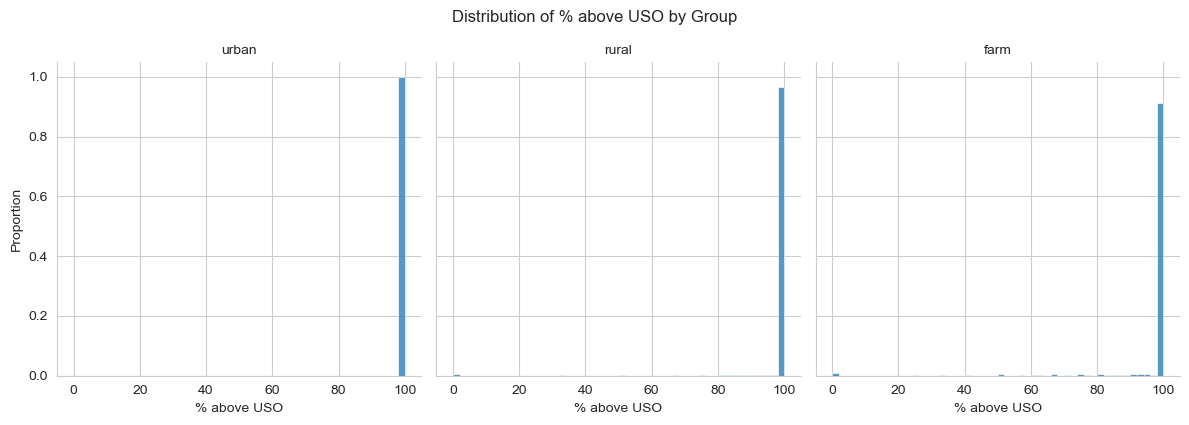

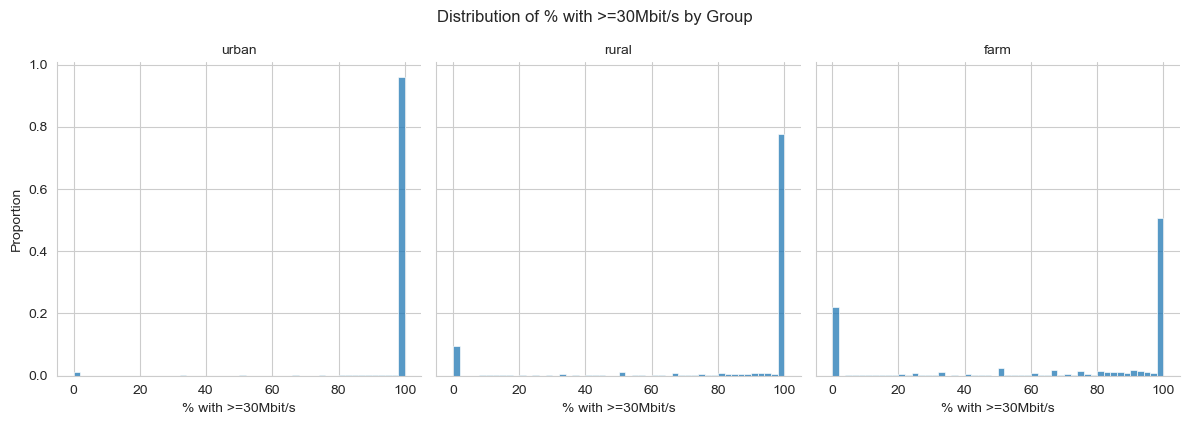

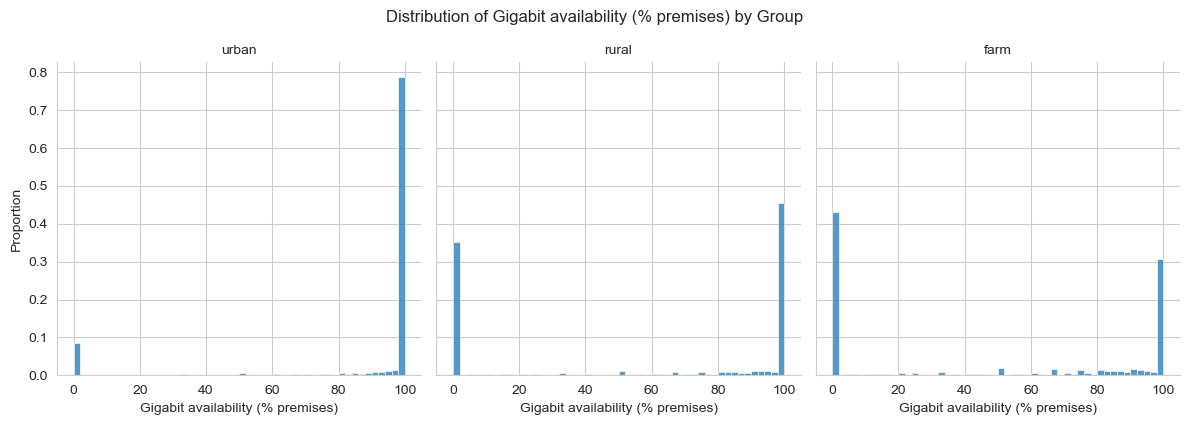

In [12]:


group_col = "group"

count = 1

for var in vars_to_test:

    # -----------------------------
    # PREP VARIABLE
    # -----------------------------
    df = gdf.copy()
    df[var] = pd.to_numeric(df[var], errors="coerce")
    df = df.dropna(subset=[var])

    # optional: avoid log(0) issue
    df[var] = df[var] + 0.01

    # -----------------------------
    # FACET HISTOGRAM
    # -----------------------------
    g = sns.displot(
        data=df,
        x=var,
        col=group_col,
        col_order=["urban", "rural", "farm"],
        bins=50,
        kde=False,                # simpler + more stable
        stat="probability",       # proportion
        common_norm=False,
        height=4,
        aspect=1
    )


    # -----------------------------
    # LABELS
    # -----------------------------
    g.set_titles("{col_name}")
    g.set_axis_labels(var, "Proportion")
    
    plt.suptitle(f"Distribution of {var} by Group", y=1.05)
    fp = '/Users/pedrickr/Documents/ADR/Digital_Inclusion/facet_distribution' + str(count) +'.png'
    g.savefig(fp, dpi=300, bbox_inches="tight")
    count = count + 1
    plt.show()

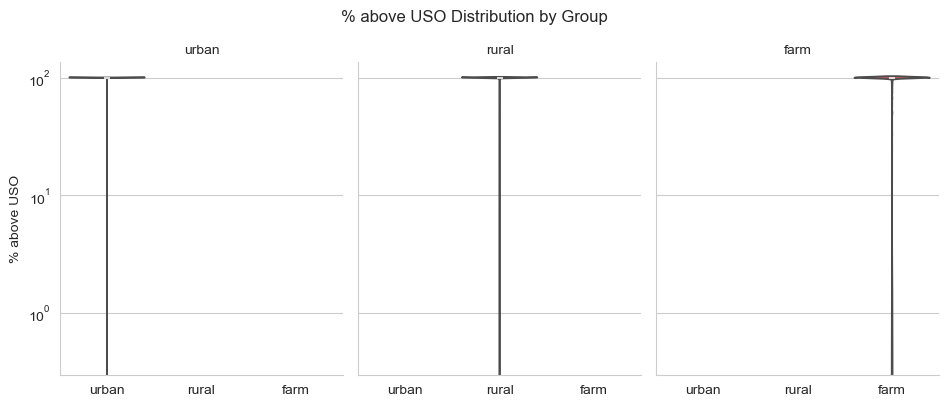

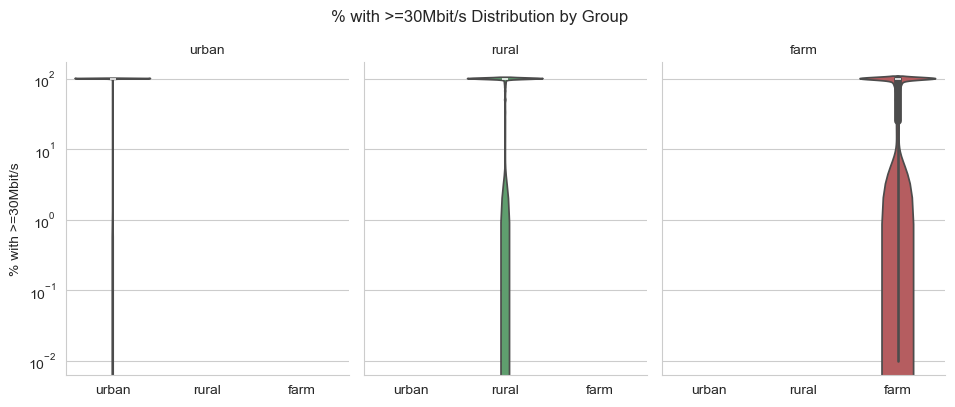

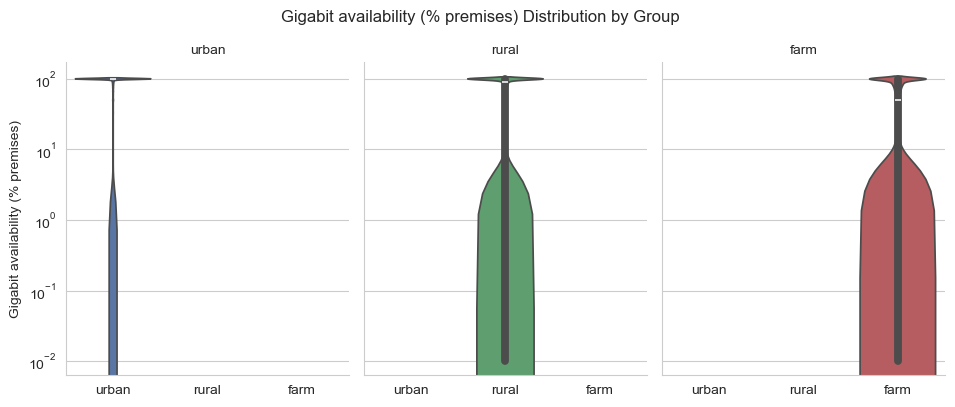

In [14]:
group_order = ["urban", "rural", "farm"]
count = 1

for var in vars_to_test:

    # -----------------------------
    # PREP DATA
    # -----------------------------
    df = gdf.copy()
    df[var] = pd.to_numeric(df[var], errors="coerce")
    df = df.dropna(subset=[var])

    # avoid log(0)
    df[var] = df[var] + 0.01

    # -----------------------------
    # FACET VIOLIN PLOT
    # -----------------------------
    g = sns.catplot(
        data=df,
        x="group",
        y=var,
        order=group_order,
        col="group",               # ← facet by group
        col_order=group_order,
        kind="violin",
        inner="box",              # ✅ boxplot inside violin
        palette=["#4c72b0", "#55a868", "#c44e52"],
        height=4,
        aspect=0.8,
        sharey=True
    )

    # -----------------------------
    # LOG SCALE
    # -----------------------------
    for ax in g.axes.flatten():
        ax.set_yscale("log")
        ax.set_xlabel("")  # cleaner look

    # -----------------------------
    # TITLES + LABELS
    # -----------------------------
    g.set_titles("{col_name}")
    g.set_axis_labels("", var)


    plt.suptitle(f"{var} Distribution by Group", y=1.05)

    fp = '/Users/pedrickr/Documents/ADR/Digital_Inclusion/facet_violin' + str(count) +'.png'
    g.savefig(fp, dpi=300, bbox_inches="tight")
    count = count + 1
    
    plt.show()

In [15]:
# ==========================================
# DESCRIPTIVE STATISTICS TABLE
# ==========================================

rows = []

for var in vars_to_test:

    row = {"Variable": var}

    # -----------------------------
    # GROUP-LEVEL STATISTICS
    # -----------------------------
    for g in gdf['group'].unique():
        vals = pd.to_numeric(
            gdf.loc[gdf['group'] == g, var],
            errors="coerce"
        )

        row[f"{g} (M)"] = vals.mean()
        row[f"{g} (SD)"] = vals.std()

    # -----------------------------
    # OVERALL ("ALL") STATISTICS
    # -----------------------------
    vals_all = pd.to_numeric(gdf[var], errors="coerce")

    row["All (M)"] = vals_all.mean()
    row["All (SD)"] = vals_all.std()
    row["P90 (All)"] = vals_all.quantile(0.9)
    row["Missing (%)"] = vals_all.isna().mean() * 100

    rows.append(row)

table = pd.DataFrame(rows).round(2)

table

,Variable,urban (M),urban (SD),rural (M),rural (SD),farm (M),farm (SD),All (M),All (SD),P90 (All),Missing (%)
0,% above USO,99.95,1.65,98.67,9.27,96.87,13.58,99.49,5.71,100.0,0.0
1,% with >=30Mbit/s,97.94,12.68,86.46,31.18,68.51,41.46,93.71,22.15,100.0,0.0
2,Gigabit availability (% premises),87.67,30.13,58.14,46.30,47.53,45.58,78.42,38.46,100.0,0.0


In [16]:
# ==========================================
# NON-PARAMETRIC GROUP COMPARISON TESTS
# (KRUSKAL–WALLIS + DUNN POST HOC)
# ==========================================

results = []

for var in vars_to_test:

    print(f"\n--- {var} ---")

    groups = []

    # -----------------------------
    # EXTRACT GROUP VALUES
    # -----------------------------
    for g in gdf['group'].unique():
        vals = gdf.loc[gdf['group'] == g, var].dropna()

        if len(vals) > 0:
            groups.append(vals)
            print(f"{g}: n = {len(vals)}")

    if len(groups) < 2:
        print("Skipping (not enough groups)")
        continue

    # -----------------------------
    # KRUSKAL–WALLIS TEST
    # -----------------------------
    stat, p = kruskal(*groups)

    # -----------------------------
    # EFFECT SIZE (EPSILON-SQUARED)
    # -----------------------------
    n = sum(len(g) for g in groups)
    k = len(groups)
    eps_sq = (stat - k + 1) / (n - k)

    print(f"KW = {stat:.3f}, p = {p:.3e}, epsilon² = {eps_sq:.3f}")

    # -----------------------------
    # DUNN’S POST HOC TEST
    # -----------------------------
    dunn = sp.posthoc_dunn(
        gdf[['group', var]].dropna(),
        val_col=var,
        group_col='group',
        p_adjust='holm'
    )

    display(dunn)

    results.append({
        "variable": var,
        "kw_stat": stat,
        "p_value": p,
        "epsilon_sq": eps_sq
    })

summary = pd.DataFrame(results)

summary


--- % above USO ---
urban: n = 1270553
rural: n = 453445
farm: n = 82683
KW = 61562.555, p = 0.000e+00, epsilon² = 0.034


,farm,rural,urban
farm,1.0,0.0,0.0
rural,0.0,1.0,0.0
urban,0.0,0.0,1.0



--- % with >=30Mbit/s ---
urban: n = 1270553
rural: n = 453445
farm: n = 82683
KW = 253129.114, p = 0.000e+00, epsilon² = 0.140


,farm,rural,urban
farm,1.0,0.0,0.0
rural,0.0,1.0,0.0
urban,0.0,0.0,1.0



--- Gigabit availability (% premises) ---
urban: n = 1270553
rural: n = 453445
farm: n = 82683
KW = 254647.878, p = 0.000e+00, epsilon² = 0.141


,farm,rural,urban
farm,1.0,0.0,0.0
rural,0.0,1.0,0.0
urban,0.0,0.0,1.0


,variable,kw_stat,p_value,epsilon_sq
0,% above USO,61562.554919,0.0,0.034074
1,% with >=30Mbit/s,253129.114365,0.0,0.140106
2,Gigabit availability (% premises),254647.878131,0.0,0.140947


In [17]:
# ==========================================
# SPATIAL WEIGHTS (K-NEAREST NEIGHBOURS)
# ==========================================

# ensure point geometry (required for KNN)
if gdf.geometry.iloc[0].geom_type != "Point":
    gdf["geometry"] = gdf.centroid

# -----------------------------
# BUILD KNN WEIGHTS
# -----------------------------
w = KNN.from_dataframe(gdf, k=5)

# row-standardisation
w.transform = "r"

print("Islands (no neighbours):", w.islands)

Islands (no neighbours): []


In [18]:
# ==========================================
# GLOBAL SPATIAL AUTOCORRELATION (MORAN'S I)
# ==========================================

moran_results = []

for var in vars_to_test:

    # -----------------------------
    # COMPUTE MORAN'S I
    # -----------------------------
    mi = Moran(gdf[var].values, w)

    print(f"\n{var}")
    print(f"Moran's I = {mi.I:.3f}, p = {mi.p_sim:.4f}")

    moran_results.append({
        "variable": var,
        "Moran_I": mi.I,
        "p_value": mi.p_sim
    })

moran_df = pd.DataFrame(moran_results)

moran_df


% above USO
Moran's I = 0.373, p = 0.0010

% with >=30Mbit/s
Moran's I = 0.567, p = 0.0010

Gigabit availability (% premises)
Moran's I = 0.637, p = 0.0010


,variable,Moran_I,p_value
0,% above USO,0.372967,0.001
1,% with >=30Mbit/s,0.566824,0.001
2,Gigabit availability (% premises),0.637233,0.001


In [21]:
gdf_rural = gpd.read_parquet('/Users/pedrickr/Documents/ADR/Digital_Inclusion/rural_ofcom_pc_centroids.parquet')
gdf_farming = gpd.read_parquet('/Users/pedrickr/Documents/ADR/Digital_Inclusion/farm_ofcom_pc_centroids.parquet')

In [22]:
# invert so higher = better (CRITICAL)

gdf_rural['group'] = 'rural'
gdf_rural["% above USO"] = 100 - gdf["% of premises below the USO"]
gdf_rural["% with >=30Mbit/s"] = 100 - gdf["% of premises unable to receive 30Mbit/s"]

vars_to_test = [
    "% above USO",
    "% with >=30Mbit/s",
    "Gigabit availability (% premises)"
]

# ensure numeric
for col in vars_to_test:
    gdf_rural[col] = pd.to_numeric(gdf_rural[col], errors="coerce")

gdf_rural = gdf_rural.dropna(subset=vars_to_test + ['group'])

In [23]:
# invert so higher = better (CRITICAL)

gdf_farming['group'] = 'farming'
gdf_farming["% above USO"] = 100 - gdf["% of premises below the USO"]
gdf_farming["% with >=30Mbit/s"] = 100 - gdf["% of premises unable to receive 30Mbit/s"]

vars_to_test = [
    "% above USO",
    "% with >=30Mbit/s",
    "Gigabit availability (% premises)"
]

# ensure numeric
for col in vars_to_test:
    gdf_farming[col] = pd.to_numeric(gdf_farming[col], errors="coerce")

gdf_farming = gdf_farming.dropna(subset=vars_to_test + ['group'])

In [24]:
# ===============================
# EXTRACT COORDINATES FOR KNN
# ===============================

from sklearn.neighbors import NearestNeighbors

rural_coords = np.column_stack((
    gdf_rural.geometry.x,
    gdf_rural.geometry.y
))

farming_coords = np.column_stack((
    gdf_farming.geometry.x,
    gdf_farming.geometry.y
))



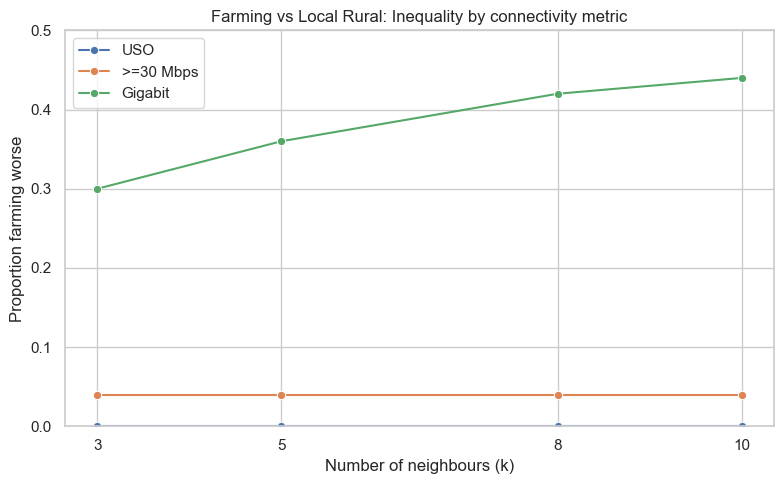

In [25]:
# Convert to long format
data = pd.DataFrame({
    "k": [3, 5, 8, 10],
    "USO": [0.00, 0.00, 0.00, 0.00],
    ">=30 Mbps": [0.04, 0.04, 0.04, 0.04],
    "Gigabit": [0.30, 0.36, 0.42, 0.44]
})

df_long = data.melt(
    id_vars="k",
    var_name="Metric",
    value_name="Proportion worse"
)

# Plot
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df_long,
    x="k",
    y="Proportion worse",
    hue="Metric",
    marker="o"
)

# Labels
plt.xlabel("Number of neighbours (k)")
plt.ylabel("Proportion farming worse")
plt.title("Farming vs Local Rural: Inequality by connectivity metric")

plt.ylim(0, 0.5)
plt.xticks([3, 5, 8, 10])

plt.legend(title="")
plt.tight_layout()

plt.show()

<Axes: xlabel='k', ylabel='Proportion worse'>

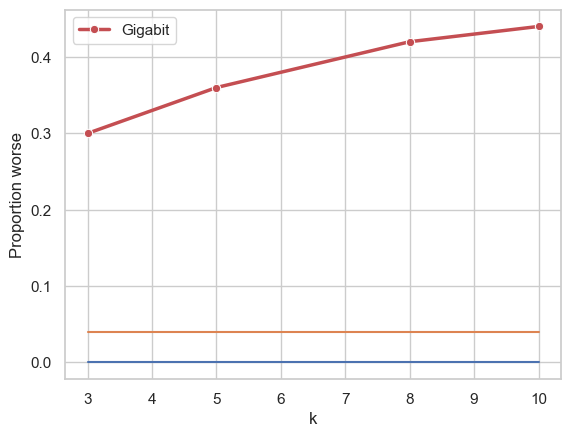

In [26]:
sns.lineplot(
    data=df_long[df_long["Metric"] != "Gigabit"],
    x="k",
    y="Proportion worse",
    hue="Metric",
    linewidth=1.5,
    legend=False
)

sns.lineplot(
    data=df_long[df_long["Metric"] == "Gigabit"],
    x="k",
    y="Proportion worse",
    color="#C44E52",
    marker="o",
    linewidth=2.5,
    label="Gigabit"
)